In [1]:
import numpy as np
import pytreenet as ptn
from copy import deepcopy
from scipy.linalg import expm
from pytreenet.util import copy_object


In [2]:
def A_prime_dict(mps, mps_tilde):
    """"
    Function to build the A_prime matrixes in A.2
    Args:
        mps: MPS object
        mps_tilde: MPS object
    Returns:
        tensors_prime: Dictionary with the A_prime matrices
    """
    tensors = []
    tensors_prime = {}

    # Iterate over the sites
    for i in range(len(mps.nodes) - 1):
        # Extract the tensors
        A1 = mps.tensors[f"site{i}"][..., 0]
        A1_tilde = mps_tilde.tensors[f"site{i}"][..., 0]
        A2 = mps.tensors[f"site{i}"][..., 1]
        A2_tilde = mps_tilde.tensors[f"site{i}"][..., 1]

        # Combine the tensors
        tensors.append(A1 + A2)
        tensors.append(A1_tilde + A2_tilde)

        # Create the combined tensor
        A_0 = np.block([[A1, np.zeros_like(A1)], [np.zeros_like(A1), A1_tilde]])
        A_1 = np.block([[np.zeros_like(A2), A2], [A2_tilde, np.zeros_like(A2)]])
        A_prime = A_0 + A_1
        tensors_prime[mps.nodes[f"site{i}"].identifier] = A_prime

    # Handle the last site
    i = len(mps.nodes) - 1
    C1 = mps.tensors[f"site{i}"][..., 0].reshape(mps.tensors[f"site{i}"][..., 0].shape[0], 1)
    C1_tilde = mps_tilde.tensors[f"site{i}"][..., 0].reshape(mps_tilde.tensors[f"site{i}"][..., 0].shape[0], 1)
    C2 = mps.tensors[f"site{i}"][..., 1].reshape(mps.tensors[f"site{i}"][..., 1].shape[0], 1)
    C2_tilde = mps_tilde.tensors[f"site{i}"][..., 1].reshape(mps_tilde.tensors[f"site{i}"][..., 1].shape[0], 1)

    tensors.append(C1 + C2)
    tensors.append(C1_tilde + C2_tilde)

    C_0 = np.block([[C1], [C1_tilde]])
    C_1 = np.block([[C2], [C2_tilde]])
    C_prime = C_0 + C_1
    tensors_prime[mps.nodes[f"site{i}"].identifier] = C_prime

    return tensors_prime

In [4]:
def normalize_ttn(ttn: ptn.TreeTensorNetwork , to_copy = False):
   """
    Normalize a tree tensor network.
    Args:
        ttn : TreeTensorNetwork
        The tree tensor network to normalize.
        to_copy : bool, optional
                  If True, the input tree tensor network is not modified and a new tree tensor network is returned.
                  If False, the input tree tensor network is modified and returned.
                  Default is False.
    Returns : 
        The normalized tree tensor network.
    """
   ttn_normalized = copy_object(ttn, deep=to_copy)
   if len(ttn_normalized.nodes) == 1:
       node_id = list(ttn_normalized.nodes.keys())[0]
       tensor = ttn_normalized.tensors[node_id]
       indices  = tuple(ttn_normalized.nodes[node_id].open_legs)
       norm = np.sqrt(np.tensordot(tensor,tensor.conj(), axes = (indices , indices) ))
       ttn_normalized.tensors[node_id] = ttn_normalized.tensors[node_id] / norm
   else :    
      norm = ptn.contract_two_ttns(ttn_normalized,ttn_normalized.conjugate())
      for node_id in list(ttn_normalized.nodes.keys()):
         norm = ptn.contract_two_ttns(ttn_normalized,ttn_normalized.conjugate())
         ttn_normalized.tensors[node_id] /= np.sqrt(norm)
   return ttn_normalized

def normalize_tensor(tensor): 
    """
     Normalize a tensor.
     Args:
          tensor : np.ndarray
     Returns : 
          The normalized tensor.
     """
    indices  = range(tensor.ndim)
    norm = np.sqrt(np.tensordot(tensor,tensor.conj(), axes = (indices , indices) ))
    return tensor / norm

In [5]:
##------------------------------------##
## Test the functions : normalize_ttn ##
##------------------------------------##

## MPS ##
shapes = [(5, 2), (5, 7, 2), (7, 3, 2), (3, 6, 2), (6, 30, 2), (30, 2)]
tensors1 = [ptn.crandn(shape) for shape in shapes]
mps1 = ptn.MatrixProductState.from_tensor_list(tensors1,root_site=5,node_prefix="site")

print( ptn.contract_two_ttns(mps1,mps1.conjugate()))
mps1_normalized = normalize_ttn(mps1 , to_copy = False) # default is False
print( ptn.contract_two_ttns(mps1,mps1.conjugate()))
print(ptn.contract_two_ttns(mps1_normalized,mps1_normalized.conjugate()))

## TTN ##
ttn1 = ptn.random_big_ttns_two_root_children()

print("contraction befor normalization : " , ptn.contract_two_ttns(ttn1,ttn1.conjugate()))
ttn1_normalized = normalize_ttn(ttn1 , to_copy = True)
print( ptn.contract_two_ttns(ttn1,ttn1.conjugate()))
print( ptn.contract_two_ttns(ttn1_normalized,ttn1_normalized.conjugate()))

(390314.07057450985+5.820766091346741e-11j)
(1+0j)
(1+0j)
contraction befor normalization :  (246485.78485147795+1.4551915228366852e-11j)
(246485.78485147795+1.4551915228366852e-11j)
(1-2.7755575615628914e-17j)


In [6]:
from typing import List, Union, Any, Dict
from pytreenet import TDVPUpdatePathFinder
from pytreenet import compute_transfer_tensor
from pytreenet import SplitMode
                        
def reduced_density_matrix_dict(ttn : ptn.TreeTensorNetwork ,max_bond_dim = np.inf , rel_tol=-np.inf, total_tol=-np.inf) -> Dict[str, np.ndarray]: 
    """Computes the reduced density matrices of a tree tensor network.
    Args:
        ttn: A tree tensor network.
        max_bond_dim: int, optional
                      The maximum bond dimension of the reduced density matrices.
                      Default is np.inf.
        rel_tol: float, optional
                 The relative tolerance for the truncation of the singular values.
                 Default is -np.inf.
        total_tol: float, optional
                   The total tolerance for the truncation of the singular values.
                   Default is -np.inf.
    Returns:
        dict: A dictionary containing the reduced density matrices of the tree tensor network.
    dict[node_id]: The reduced density matrix of the node with the given node_id.
    """
    truncation_param = {
        "max_bond_dim": max_bond_dim,
        "rel_tol": rel_tol,
        "total_tol": total_tol,}
    
    update_path = TDVPUpdatePathFinder(ttn).find_path()
    ttn = normalize_ttn(ttn, to_copy = True)
    ttn.canonical_form(update_path[0],**truncation_param)

    orthogonalization_path = []
    for i in range(len(update_path)-1):
        sub_path = ttn.path_from_to(update_path[i], update_path[i+1])
        orthogonalization_path.append(sub_path[1::])

    dict = {}
    for i, node_id in enumerate(update_path):
        contracted_legs = tuple(range(ttn.tensors[node_id].ndim - 1 )) 
        if i == len(update_path)-1:
            reduced_density = compute_transfer_tensor(ttn.tensors[node_id], contracted_legs)        
            dict[node_id] = reduced_density
        elif i == 0:
            reduced_density = compute_transfer_tensor(ttn.tensors[node_id], contracted_legs)        
            dict[node_id] = reduced_density
            next_node_id = orthogonalization_path[0][0]
            move_orth_for_path(ttn,[node_id, next_node_id], **truncation_param)
        else:
            current_orth_path = orthogonalization_path[i-1]
            move_orth_for_path(ttn,current_orth_path,**truncation_param)
            reduced_density = compute_transfer_tensor(ttn.tensors[node_id], contracted_legs)        
            dict[node_id] = reduced_density
            next_node_id = orthogonalization_path[i][0]
            move_orth_for_path(ttn,[node_id, next_node_id], **truncation_param)
    return dict   

def move_orth_for_path(ttn: ptn.TreeTensorNetwork , path: List[str] , **truncation_param):
        if len(path) == 0:
            return
        assert ttn.orthogonality_center_id == path[0]
        for i, node_id in enumerate(path[1:]):
            ttn.move_orthogonalization_center(node_id,**truncation_param)     

def reduced_density_matrix(ttn : ptn.TreeTensorNetwork ,node_id: str,
                           max_bond_dim = np.inf , rel_tol=-np.inf, total_tol=-np.inf) -> Dict[str, np.ndarray]: 
    """Computes the reduced density matrices of a tree tensor network.
    Args:
        ttn: A tree tensor network.
        node_id: str
                 The node_id of the node for which the reduced density matrix is computed.
        max_bond_dim: int, optional
                      The maximum bond dimension of the reduced density matrices.
                      Default is np.inf.
        rel_tol: float, optional
                 The relative tolerance for the truncation of the singular values.
                 Default is -np.inf.
        total_tol: float, optional
                   The total tolerance for the truncation of the singular values.
                   Default is -np.inf.
         """    
    working_ttn = normalize_ttn(ttn, to_copy = True)
    working_ttn.canonical_form(node_id,max_bond_dim = max_bond_dim, rel_tol=rel_tol,total_tol=total_tol)
    contracted_legs = tuple(range(working_ttn.tensors[node_id].ndim - 1 ))
    reduced_density = compute_transfer_tensor(working_ttn.tensors[node_id], contracted_legs)
    return reduced_density
      

In [7]:
def density_tensor(ttn: ptn.TreeTensorNetwork) -> (np.ndarray, List[str]):
    """
    Computes the density tensor of a tree tensor network.
    Args :
        ttn: TreeTensorNetwork
    Returns :
        density tensor : Tensor , 
        order : List[str]
        # order of legs =  [out_1, out_2, ..., out_n, in_1, in_2, ..., in_n] 
    """    
    ttn_cct = normalize_ttn(ttn,to_copy=True)
    tensor , order = ttn_cct.completely_contract_tree()

    ket = tensor
    bra = tensor.conj()
    ket = ket.reshape(ket.shape + (1,))
    bra = bra.reshape(bra.shape + (1,))

    return  np.tensordot(bra,ket,axes=([-1],[-1])) , order

def density_ttno(ttn):
    """
    Computes the ttno with density tensor of a ttn.
    Args :
        ttn: TreeTensorNetwork
    Returns :
        ttno : TTNO 
        order of legs =  [out_1, in_1, ..., out_n, in_n]
    """
    tensor , order = density_tensor(ttn)
    leg_dict = {order[i] : i for i in range(len(order))}
    return ptn.TTNO.from_tensor(ttn, tensor, leg_dict) 

In [8]:
"""
First did it like this, but I guess completely_contract_tree is more 
costly that moving the canoical center. I wonder why the results are
not same!
"""

def reduced_density_matrix_2(ttn: ptn.TreeTensorNetwork ,node_id : str) -> np.ndarray:
    """
    Computes the reduced density matrix of a node in a tree tensor network.
    Args :
        ttn: TreeTensorNetwork
        node_id: str
    Returns :
        pho : Tensor
    """
    pho , order = density_tensor(ttn)
    dim = pho.ndim
    for i in range(len(order)):
        if order[i] == node_id:
            count = i
    for i in range(count):
        pho = np.trace(pho, axis1 = 0, axis2 = pho.ndim//2)
    for i in range(count +1 , dim//2):
        pho = np.trace(pho, axis1 = 1, axis2 = 1 + pho.ndim//2)
    return pho

""""
I wonder why the results are not same!
"""
ttn = ptn.random_big_ttns_two_root_children()
node_id = 'site2'
pho = reduced_density_matrix_2(ttn,node_id)
pho_tilde = reduced_density_matrix_dict(ttn)[node_id]
print(np.allclose(pho,pho_tilde)) ######### Fails

False


In [89]:
ttn1 = ptn.random_big_ttns_two_root_children()
ttn2 = ptn.random_big_ttns_two_root_children()
##---------------------##
## Full density tensor ##
##---------------------##

## For pure states : (density tensor)^2 = density tensor 
pho , order = density_tensor(ttn) 
# order = ['site0', 'site1', 'site2', 'site3', 'site4', 'site5', 'site6', 'site7']
# density tensor * density tensor = density tensor :
tensor = np.tensordot(pho,pho,axes=((8,9,10,11,12,13,14,15),(0,1,2,3,4,5,6,7)))
print(np.allclose(tensor,pho))

## trace of density tensor = 1
def tensor_trace(pho):
    """"
    Args :
        pho : Tensor
    Returns :
        trace : float
    """
    for _ in range(pho.ndim//2):
        pho = np.trace(pho, axis1 = 0, axis2 = pho.ndim//2)
    return pho

print(np.allclose(tensor_trace(pho),1))

##---------------------------##
## Full density tensor(ttno) ##
##---------------------------##

ttn = ptn.random_big_ttns_two_root_children()
pho_ttno = density_ttno(ttn)

## trace of density tensor = 1
def ttno_trace(pho):
    ttno_cct = deepcopy(pho)
    ttno_cct = ttno_cct.completely_contract_tree()[0] 
    for _ in range(ttno_cct.ndim//2):
        ttno_cct = np.trace(ttno_cct, axis1 = 0, axis2 = 1)
    return ttno_cct

print(np.allclose(ttno_trace(pho_ttno),1))

## check density_ttno and density_tensor compatibility : 
ttn = ptn.random_small_ttns()
pho , order = density_tensor(ttn) 
pho_ttno = density_ttno(ttn)
np.allclose(pho_ttno.completely_contract_tree()[0],pho.transpose(0,3,1,4,2,5))

##------------------------##
## Reduced density tensor ##
##------------------------##

ttn = ptn.random_big_ttns_two_root_children()
node_id = 'site0'
# first method :
pho_ref_1 = reduced_density_matrix_dict(ttn)[node_id]
pho_ref_2 = reduced_density_matrix(ttn,node_id)
# second method :
pho = reduced_density_matrix_2(ttn,node_id)

# trace of reduced density tensor = 1
print(np.trace(pho, axis1 = 0, axis2 = 1))
print(np.trace(pho_ref_1, axis1 = 0, axis2 = 1))
print(np.trace(pho_ref_2, axis1 = 0, axis2 = 1))

# Check Hermiticity : 
print(np.allclose(pho,pho.conjugate().T))
print(np.allclose(pho_ref_1,pho_ref_1.conjugate().T))
print(np.allclose(pho_ref_2,pho_ref_2.conjugate().T))

# calculate explicitly the reduced density tensor of a node in a tree tensor network
node_id = 'site4'
ttn = normalize_ttn(ttn,to_copy=True)
ttn.canonical_form(node_id,max_bond_dim = np.inf , rel_tol=-np.inf, total_tol=-np.inf)
C = ttn.tensors[node_id]
reduced_density_matrix_dir = ptn.compute_transfer_tensor(C, tuple(range(C.ndim - 1)))


reduced_density_matrix_ref_1 = reduced_density_matrix_dict(ttn)[node_id]
reduced_density_matrix_ref_2 = reduced_density_matrix(ttn,node_id)

print(np.allclose(reduced_density_matrix_dir,reduced_density_matrix_ref_1))
print(np.allclose(reduced_density_matrix_dir,reduced_density_matrix_ref_2))


True
True
True
(0.9999999999999999+0j)
(0.9999999999999962+1.3450397695031461e-17j)
(0.9999999999999976+6.609440311864143e-18j)
True
True
True
True
True


In [10]:
# I changed .canonical_form and .ttn to 
# 1. use SVD instead of QR
# 2. define new function because the canonical_form transforms ttns only to site cannonical form.
#    - complete_canonical_form transforms all tensors to left Isometry 
#      with respect to root site controlled by SVD truncation parameters.


# Test : ttn.canonical_form(node_id, max_bond_dim = np.inf , rel_tol=-np.inf, total_tol=-np.inf)
#        ttn.complete_canonical_form(max_bond_dim = np.inf , rel_tol=-np.inf, total_tol=-np.inf)


### MPS ###
shapes = [(5, 2), (5, 7, 2), (7, 3, 2), (3, 6, 2), (6, 30, 2), (30, 2)]
tensors1 = [ptn.crandn(shape) for shape in shapes]
mps1 = ptn.MatrixProductState.from_tensor_list(tensors1,root_site=5,node_prefix="site")

## test canonical_form for "site2" :
ref_contracted = ptn.contract_two_ttns(mps1,mps1.conjugate())
mps1.canonical_form("site2", max_bond_dim = np.inf , rel_tol=-np.inf, total_tol=-np.inf)
direct_contracted = ptn.compute_transfer_tensor(mps1.tensors["site2"], tuple(range(mps1.tensors["site2"].ndim )))
print(np.allclose(ref_contracted, direct_contracted))

## test complete_canonical_form : 
mps1_norm = ptn.contract_two_ttns(mps1,mps1.conjugate())
norm = ptn.complete_canonical_form(mps1 ,max_bond_dim = np.inf , rel_tol=-np.inf, total_tol=-np.inf)
    # check the norm 
print(np.allclose(mps1_norm,norm))
print(np.allclose(ptn.contract_two_ttns(mps1,mps1.conjugate()),1))
    # check the orthogonality of root site = "site5"
Identity = ptn.compute_transfer_tensor(mps1.tensors[mps1.root_id], (0,1) )
print(np.allclose(Identity,1))
    # check the orthogonality of "site3"
Identity = ptn.compute_transfer_tensor(mps1.tensors["site3"], (1,2) )
print(np.allclose(Identity,np.eye(4)))
    # check the orthogonality of leaf site = "site0"
print(np.allclose(ptn.compute_transfer_tensor(mps1.tensors["site0"], (1,) ),np.eye(2)))



### TTN ###
ttn1 = ptn.random_big_ttns_two_root_children()

# test canonical_form for "site3"
direct_contracted = ptn.contract_two_ttns(ttn1,ttn1.conjugate())
ttn1.canonical_form("site3", max_bond_dim = np.inf , rel_tol=-np.inf, total_tol=-np.inf)
ref_contracted = ptn.compute_transfer_tensor(ttn1.tensors["site3"], tuple(range(ttn1.tensors["site3"].ndim )))
print(np.allclose(ref_contracted, direct_contracted))

## test complete_canonical_form :
ttn1_norm = ptn.contract_two_ttns(ttn1,ttn1.conjugate())
_ , norm = ttn1.complete_canonical_form(max_bond_dim = np.inf , rel_tol=-np.inf, total_tol=-np.inf)
    # check the norm 
print(np.allclose(ttn1_norm,norm))
print(np.allclose(ptn.contract_two_ttns(ttn1,ttn1.conjugate()),1)) 
    # check the orthogonality of root site = "site0"
print(np.allclose(ptn.compute_transfer_tensor(ttn1.tensors[ttn1.root_id], (0,1,2) ),1))
    # check the orthogonality of leaf site = "site4"
print(np.allclose(ptn.compute_transfer_tensor(ttn1.tensors["site4"], (1,) ),np.eye(2)))
    # check the orthogonality of "site3"
Identity = ptn.compute_transfer_tensor(ttn1.tensors["site3"], (1,2,3) )
print(np.allclose(Identity,np.eye(2)))


True
True
True
True
True
True
True
True
True
True
True
True


# Krylov space 

In [55]:
"""
In first method, I applied one site projector at ecah step(along the same path as tdvp)
"""
# Initialize a random mps and ttn and their random hamiltonian : 

## MPS ##
"""
0 --- 1 --- 2 --- 3 --- 4 ---- 5
|     |     |     |     |      |

# order of legs =  [right_child, left_child, open_leg]
"""
shapes = [(5, 2), (5, 7, 2), (7, 3, 2), (3, 6, 2), (6, 30, 2), (30, 2)]
tensors1 = [ptn.crandn(shape) for shape in shapes]
mps1 = ptn.MatrixProductState.from_tensor_list(tensors1,root_site=5,node_prefix="site")

"""
Question : 
tp = ptn.random_tensor_product(mps1, num_operators= len(mps1))
H = ptn.Hamiltonian(tp)
hamiltonian = ptn.TTNO.from_hamiltonian(H,mps1)
this method no longer works (Error: state_diagram.obtain_tensor_shape)
"""
tensor = ptn.crandn([2,2,2,2,2,2,
                     2,2,2,2,2,2])
leg_dict = {"site0": 0, "site1": 1, "site2": 2, "site3": 3, "site4": 4, "site5": 5}
ham_mps = ptn.TTNO.from_tensor(mps1, tensor, leg_dict)


"""
Question : why ptn.Krylov is not working? 
"""
from pytreenet import Krylov
Krylov_space = Krylov(mps1, ham_mps)
Krylov_space.run(num_steps=4)
print(Krylov_space.results[0] == Krylov_space.initial_state)
print(len(Krylov_space.results) == 5)
print(Krylov_space.results[0] == Krylov_space.initial_state)
# Krylov_space.results[1] = P*hamiltonian |inisial_state>
# Krylov_space.results[2] = P*hamiltonian^2 |Krylov_space.results[1]>
# Krylov_space.results[3] = P*hamiltonian^3 |Krylov_space.results[2]>
# Krylov_space.results[4] = P*hamiltonian^4 |Krylov_space.results[3


## TTN ##
ttn1 = ptn.random_big_ttns_two_root_children()
ham_ttn = ptn.TTNO.from_hamiltonian(ptn.random_hamiltonian_compatible(),ttn1)

Krylov_space = Krylov(ttn1, ham_ttn)
Krylov_space.run(num_steps=4)
print(Krylov_space.results[0] == Krylov_space.initial_state)


100%|██████████| 5/5 [00:00<00:00, 50.57it/s]


True
True
True
(1591612.4105078098+1.7462298274040222e-10j)
(1.646686483545369e+28-1099511627776j)
(4.7055988340715965e+35+4.611686018427388e+19j)
(1.5039168318920744e+43-3.713820117856141e+27j)


100%|██████████| 5/5 [00:00<00:00, 263.35it/s]

True


In [12]:
"""
I wanted to orthogonalize the outcome at each step to the previous states, but 
I could not find a way to ortogonilize two ttns against each other.
I tried to orthogonalize each tensors seperately, but it did not work.
"""

def orthogonalize_against(ttn1 , ttn2):
    """
    Orthogonalize all lolace tensors of ttn1 against ttn2.
    Args:
        ttn1 : TreeTensorNetwork
        ttn2 : TreeTensorNetwork
    """
    for i in range(len(ttn1.nodes)):
        shape = ttn1.tensors[f"site{i}"].shape
        a = ttn1.tensors[f"site{i}"].reshape(-1)
        b = deepcopy(ttn2.tensors[f"site{i}"])
        b = normalize_tensor(b)
        b = b.reshape(-1)
        prod = np.tensordot(b.conj(), a , axes = (0,0) )
        a = a - b * prod
        a = a / np.sqrt(ptn.contract_two_ttns(ttn1,ttn1.conjugate()))
        ttn1.tensors[f"site{i}"] = np.reshape(a,shape)
    return ttn1 , ttn2
  
## Test : (fails)
shapes = [(5, 2), (5, 7, 2), (7, 3, 2), (3, 6, 2), (6, 30, 2), (30, 2)]
tensors1 = [ptn.crandn(shape) for shape in shapes]
tensors2 = [ptn.crandn(shape) for shape in shapes]
mps1 = ptn.MatrixProductState.from_tensor_list(tensors1,root_site=5,node_prefix="site")
mps2 = ptn.MatrixProductState.from_tensor_list(tensors2,root_site=5,node_prefix="site")
orthogonalize_against(mps1,mps2)

a = mps1.tensors["site2"]
b = mps2.tensors["site2"]
print(np.allclose(np.tensordot(b.conj(), a , axes = ((0,1,2),(0,1,2))), 0))
print(ptn.contract_two_ttns(mps1,mps1.conjugate()))
print(ptn.contract_two_ttns(mps2,mps2.conjugate()))
print(np.allclose(ptn.contract_two_ttns(mps1,mps2.conjugate()),0)) # not orthogonal 

True
(0.9315990645605543+2.7755575615628914e-17j)
(2482088.1298340885+1.4551915228366852e-10j)
False


In [61]:
"""
In this method, I contracted hamiltonian(TTNO) to the state(TTN) at each site. 
the bond dimension was growing exponentially, so at each step I transformed
the state to the complete canonical form, where bond dimension are controlled by
SVD truncation parameters.
"""

from tqdm import tqdm

def Krylov_space(initial_state,  hamiltonian , num_steps, **truncate_params):
    """
    Compute the Krylov space an initial state under a given Hamiltonian.

    Args:
        initial_state (TreeTensorNetwork): The initial state as a TreeTensorNetwork object.
        hamiltonian (TTNO): The Hamiltonian as a TTNO (Tensor Train Network Operator) object.
        num_steps (int): The number of steps to evolve the state.
        **truncate_params (dict): max_bond_dim, rel_tol, total_tol, which are the SVD truncation parameters.
    Returns:
        list: A list of TreeTensorNetwork objects representing the state at each step.
              All states are normlized and in complete canonical form with respect to the root site.
    """
    results = list(np.zeros(num_steps + 1))
    results[0] = initial_state
    ttn = deepcopy(initial_state)
    for i in tqdm(range(num_steps)):
        ttn = apply_hamiltonian(ttn ,hamiltonian)
        ttn , _ = ttn.complete_canonical_form(**truncate_params)
        results[i+1] = ttn
        # orthogonalize self.results[i+1] against self.results[i+1]
    return results

def apply_hamiltonian(ttn, ttno):
    state = deepcopy(ttn)
    for node_id in ttn.nodes:
        n = state.nodes[node_id].nneighbours()
        tensor = np.tensordot(state.tensors[node_id], 
                              ttno.tensors[node_id], 
                              axes=(-1, n+1))
        legs = []
        list1 = list(range(n))
        list2 = list(range(n, 2 * n))
        legs = list(zip(list1, list2))
        shape = []
        for index in legs:
            shape.append(tensor.shape[index[0]] * tensor.shape[index[1]])
        shape.append(tensor.shape[-1])
        transpose = []
        for legs in legs:
            transpose.append(legs[0])
            transpose.append(legs[1])
        transpose.append(tensor.ndim-1)

        tensor = np.transpose(tensor, transpose)
        state.tensors[node_id] = np.reshape(tensor, shape)
        state.nodes[node_id].link_tensor(ttn.tensors[node_id])
    return state

In [91]:
# initialize mps : mps1

# Antiferromagnet state
mps_up = ptn.MatrixProductState.constant_product_state(state_value = 0,
                                                     dimension =  2,
                                                     num_sites = 15,
                                                     node_prefix = "site", # default 
                                                     root_site = 14)

mps_down = ptn.MatrixProductState.constant_product_state(state_value = 1,
                                                     dimension =  2,
                                                     num_sites = 15,
                                                     node_prefix = "site", # default 
                                                     root_site = 14)    
mps1 = deepcopy(mps_up)
for i in range(len(mps1.nodes)):
    if i % 2 == 0:
       mps1.tensors[f"site{i}"] = mps_up.tensors[f"site{i}"]
    else:
       mps1.tensors[f"site{i}"] = mps_down.tensors[f"site{i}"]  


# Initialize a random hamiltonian(TTNO) : mpo1

X , Y , Z = ptn.pauli_matrices()
possible_operators = [X, X@Y, Z@X, Z, Y, X@Y , Z@Z, Y@X, Z@Y ] 
sites = [f"site{i}" for i in range(len(mps1.nodes))]
# List = ptn.random_symbolic_terms(num_of_terms=4, 
#                                 possible_operators=possible_operators, 
#                                 sites=sites, 
#                                 min_num_sites=2, 
#                                 max_num_sites=4, 
#                                 seed=None) ----> Error 
###########################################################
List = ptn.random_terms(num_of_terms = 5,
                        possible_operators = possible_operators,
                        sites = sites,
                        min_strength = 1,
                        max_strength = 4,
                        min_num_sites= 10,
                        max_num_sites= 14)
tp_list = [ptn.TensorProduct(term) for term in List]

H = ptn.Hamiltonian(tp_list)
H = H.pad_with_identities(mps1)
# ttno1 = ptn.TTNO.from_hamiltonian(H, mps1) ----> Error: StateDiagram.from_hamiltonian
##############################################################
tp1 = ptn.random_tensor_product(mps1, num_operators= len(mps1), possible_operators = possible_operators)
tp2 = ptn.random_tensor_product(mps1, num_operators= len(mps1), possible_operators = possible_operators)

H = ptn.Hamiltonian([tp1,tp2])
H = H.pad_with_identities(mps1)
# mpo1 = ptn.TTNO.from_hamiltonian(H,mps1) ----> Error: StateDiagram.from_hamiltonian
######################################################################################################

conversion_dictionary = {}
for i in range(len(mps1.nodes)):
    conversion_dictionary[f"{i}"] = ptn.random_hermitian_matrix(2)
for i in range(len(mps1.nodes)):
    conversion_dictionary[f"I{i}"] = np.eye(i)

dict = {}
for i in range(len(mps1.nodes)):
    dict[f"site{i}"] = f"{i}"
tp1 = ptn.TensorProduct(dict)

for i in range(len(mps1.nodes)):
    dict[f"site{i}"] = f"{len(mps1.nodes) - i-1}"
tp2 = ptn.TensorProduct(dict)

H = ptn.Hamiltonian([tp1,tp2],conversion_dictionary)
H = H.pad_with_identities(mps1)
mpo1 = ptn.TTNO.from_hamiltonian(H,mps1) # All bond dimnsions are 2 

In [87]:
results = Krylov_space(mps1, mpo1, num_steps=10, max_bond_dim = 100, rel_tol=-np.inf, total_tol=-np.inf)


# results[0] = initial_state
print(results[0] == mps1)
# results[1] = hamiltonian |inisial_state>
# results[2] = hamiltonian^2 |Krylov_space.results[1]>
# results[3] = hamiltonian^3 |Krylov_space.results[2]>
# results[4] = hamiltonian^4 |Krylov_space.results[3]>
# Check the norms 
print(ptn.contract_two_ttns(results[1],results[1].conjugate()))
print(ptn.contract_two_ttns(results[5],results[5].conjugate()))
print(ptn.contract_two_ttns(results[10],results[10].conjugate()))
# check the orthogonality of root site = "site14"
print(np.allclose(ptn.compute_transfer_tensor( results[2].tensors[ttn1.root_id], (0,)) , np.eye(2) ))
# check the orthogonality of leaf site = "site10"
print(np.allclose(ptn.compute_transfer_tensor( results[6].tensors["site10"], (1,2) ),np.eye(100)))
# the growth of bind dimensions at "site10"
print(results[0].tensors["site10"].shape)
print(results[2].tensors["site10"].shape)
print(results[4].tensors["site10"].shape)
print(results[6].tensors["site10"].shape)
print(results[8].tensors["site10"].shape)


100%|██████████| 10/10 [00:03<00:00,  3.25it/s]

True
(0.9999999999999999+0j)
(0.9999999999999999+8.326672684688674e-17j)
(1+0j)
(2, 2, 2)
(8, 8, 2)
(32, 32, 2)
(100, 100, 2)
(100, 100, 2)
True
True


# Global Bond expansion

In [127]:
shapes = [(4,2)] + [(4,4,2)]*13 + [(4,2)]
tensors = [ptn.crandn(shape) for shape in shapes]
mps = ptn.MatrixProductState.from_tensor_list(tensors,root_site=14,node_prefix="site")



100%|██████████| 10/10 [00:05<00:00,  1.79it/s]


In [128]:
# Prepare the states for bond expansion 
results = Krylov_space(mps, mpo1, num_steps=10, max_bond_dim = 100, rel_tol=-np.inf, total_tol=-np.inf)

mps1 = results[0]
mps2 = results[1]
mps3 = results[2]
mps4 = results[3]
mps5 = results[4]
mps6 = results[5]

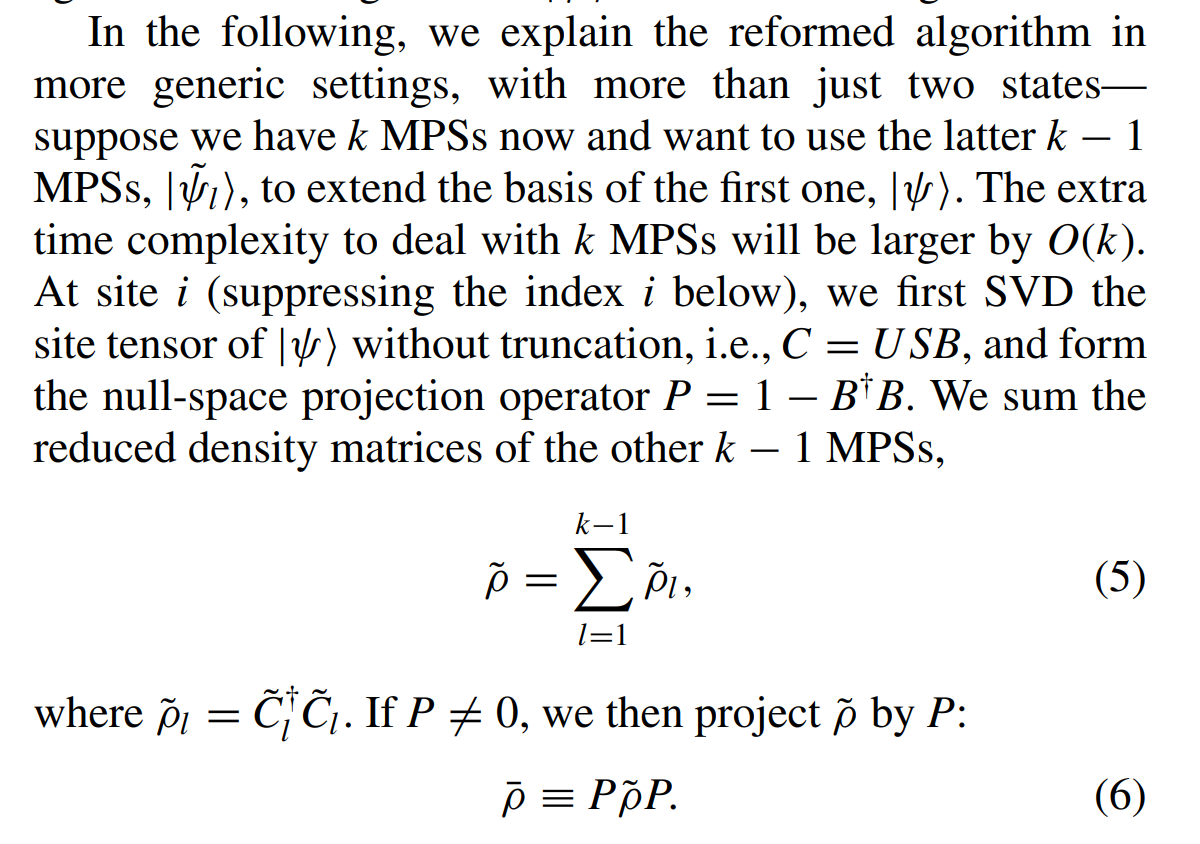


In [155]:
U , S , B = ptn.truncated_tensor_svd(mps1.tensors["site14"], (1,), (0,),
                                     max_bond_dim=np.inf , rel_tol=-np.inf, total_tol=-np.inf)
print(U.shape , S.shape , B.shape)

B_dagger = B.conj().T
B_dagger_B = B_dagger @ B 
P = np.eye(B_dagger_B.shape[0]) - B_dagger_B

pho_2 = reduced_density_matrix(mps2,"site14")
pho_3 = reduced_density_matrix(mps3,"site14")
pho_4 = reduced_density_matrix(mps4,"site14")
pho_5 = reduced_density_matrix(mps5,"site14")
pho_6 = reduced_density_matrix(mps6,"site14")
pho_tilde = pho_2 + pho_3 + pho_4 + pho_5 + pho_6

# pho_baar = P @ pho @ P ---> dimension mismatch

(2, 2) (2,) (2, 4)
